## create_dataset

In [5]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_samples = 1000

age = np.random.randint(20, 80, n_samples)
cholesterol = np.random.randint(150, 300, n_samples)
blood_pressure = np.random.randint(80, 180, n_samples)
bmi = np.random.uniform(18, 40, n_samples)
smoking = np.random.choice([0, 1], n_samples, p=[0.7, 0.3])
exercise = np.random.choice([0, 1], n_samples, p=[0.6, 0.4])

heart_disease_prob = (
    0.01 * age +
    0.005 * cholesterol +
    0.003 * blood_pressure +
    0.02 * bmi +
    0.3 * smoking -
    0.2 * exercise -
    2
)
heart_disease_prob = 1 / (1 + np.exp(-heart_disease_prob))
heart_disease = (heart_disease_prob > 0.5).astype(int)

df = pd.DataFrame({
    'age': age,
    'cholesterol': cholesterol,
    'blood_pressure': blood_pressure,
    'bmi': bmi,
    'smoking': smoking,
    'exercise': exercise,
    'heart_disease': heart_disease
})

df.to_csv('heart_disease_dataset.csv', index=False)
print(" دیتاست ذخیره شد: heart_disease_dataset.csv")
print(f" تعداد نمونه‌ها: {len(df)}")
print(f" توزیع کلاس‌ها:\n{df['heart_disease'].value_counts()}")


 دیتاست ذخیره شد: heart_disease_dataset.csv
 تعداد نمونه‌ها: 1000
 توزیع کلاس‌ها:
heart_disease
1    955
0     45
Name: count, dtype: int64


## Logistic Regression


In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report



class LogisticRegressionFromScratch:
    def __init__(self,learning_rate=0.01,n_iterations=1000,regularization=0.0):
        self.learning_rate = learning_rate
        self.n_itreations = n_iterations
        self.regularization = regularization
        self.weights = None
        self.bias = None
        self.loss_history = []
        
    
    def sigmoid(self,z):
        return 1/ (1+np.exp(-np.clip(z,-500,500)))
    
    
    def compute_loss(self,y_true,y_pred):
        epsilon = 1e-15
        y_pred = np.clip(y_pred,epsilon,1-epsilon)
        bce_loss = -np.mean(y_true*np.log(y_pred)+ (1-y_pred)*np.log(1-y_pred))
        l2_penalty  = (self.regularization/(2*len(y_true)))*np.sum(self.weights**2)
        return bce_loss + l2_penalty
    
    
    def fit(self,X,y):
        n_samples,n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for i in range(self.n_itreations):
            linear_model = np.dot(X,self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)
            
            
            loss = self.compute_loss(y,y_pred)
            self.loss_history.append(loss)
            
            dw = (1/n_samples)*np.dot(X.T,(y_pred -y))+(self.regularization/n_samples)*self.weights
            db = (1/n_samples)*np.sum(y_pred-y)
            
            
            self.weights -= self.learning_rate*dw
            self.bias -= self.learning_rate*db
            
            
            if (i+1) %100 == 0:
                print(f'Iteration {i+1}/{self.n_itreations},Loss:{loss:.4f}')
                
    def predict_proba(self,X):
        linear_model = np.dot(X,self.weights) + self.bias
        return  self.sigmoid(linear_model)
    
    
    def predict(self,X,threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)
    
df = pd.read_csv('datasets\heart_disease_dataset.csv')
X = df.drop('heart_disease',axis=1).values
y = df['heart_disease'].values


X_train,X_test,y_trian,y_test = train_test_split(X,y,test_size=0.2,random_state=6)


scaler = StandardScaler()
X_train_scaled =  scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



print("\n" + "="*60)
print(" Logistic Regression From Scratch")
print("="*60)


model_scratch = LogisticRegressionFromScratch(learning_rate=0.1,n_iterations=100,regularization=0.01)
model_scratch.fit(X_train_scaled,y_trian)

y_pred_scratch = model_scratch.predict(X_test_scaled)
acc_scratch = accuracy_score(y_test,y_pred_scratch)



print(f"\n Accuracy (Scratch): {acc_scratch:.4f}")
print(f"\n Confusion Matrix (Scratch):\n{confusion_matrix(y_test, y_pred_scratch)}")
print(f"\n Classification Report (Scratch):\n{classification_report(y_test, y_pred_scratch)}")





print("\n" + "="*60)
print(" Logistic Regression with Scikit-Learn")
print("="*60)



model_sklearn  = SklearnLR(max_iter=100,random_state=6)
model_sklearn.fit(X_train_scaled,y_trian)



y_pred_sklearn = model_sklearn.predict(X_test_scaled)
acc_sklearn = accuracy_score(y_test,y_pred_sklearn)


print(f"\n Accuracy (Scikit-Learn): {acc_sklearn:.4f}")
print(f"\n Confusion Matrix (Scikit-Learn):\n{confusion_matrix(y_test, y_pred_sklearn)}")
print(f"\n Classification Report (Scikit-Learn):\n{classification_report(y_test, y_pred_sklearn)}")





 Logistic Regression From Scratch
Iteration 100/100,Loss:0.3811

 Accuracy (Scratch): 0.9250

 Confusion Matrix (Scratch):
[[  0  15]
 [  0 185]]

 Classification Report (Scratch):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.93      1.00      0.96       185

    accuracy                           0.93       200
   macro avg       0.46      0.50      0.48       200
weighted avg       0.86      0.93      0.89       200


 Logistic Regression with Scikit-Learn

 Accuracy (Scikit-Learn): 0.9800

 Confusion Matrix (Scikit-Learn):
[[ 11   4]
 [  0 185]]

 Classification Report (Scikit-Learn):
              precision    recall  f1-score   support

           0       1.00      0.73      0.85        15
           1       0.98      1.00      0.99       185

    accuracy                           0.98       200
   macro avg       0.99      0.87      0.92       200
weighted avg       0.98      0.98      0.98    

<>:65: SyntaxWarning: invalid escape sequence '\h'
<>:65: SyntaxWarning: invalid escape sequence '\h'
C:\Users\mojta_tok6stl\AppData\Local\Temp\ipykernel_4912\1033848305.py:65: SyntaxWarning: invalid escape sequence '\h'
  df = pd.read_csv('datasets\heart_disease_dataset.csv')
c:\Users\mojta_tok6stl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mojta_tok6stl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mojta_tok6stl\anaconda3\Lib\site-packages\sklearn\metrics

## Loss Surface 

<>:23: SyntaxWarning: invalid escape sequence '\h'
<>:23: SyntaxWarning: invalid escape sequence '\h'
C:\Users\mojta_tok6stl\AppData\Local\Temp\ipykernel_4912\3297029730.py:23: SyntaxWarning: invalid escape sequence '\h'
  df = pd.read_csv('datasets\heart_disease_dataset.csv')
C:\Users\mojta_tok6stl\AppData\Local\Temp\ipykernel_4912\3297029730.py:18: RuntimeWarning: invalid value encountered in log
  loss = -np.mean(y*np.log(y_pred)+(1-y)*np.log(1-y_pred))


 Loss Surface ذخیره شد: loss_surface.png


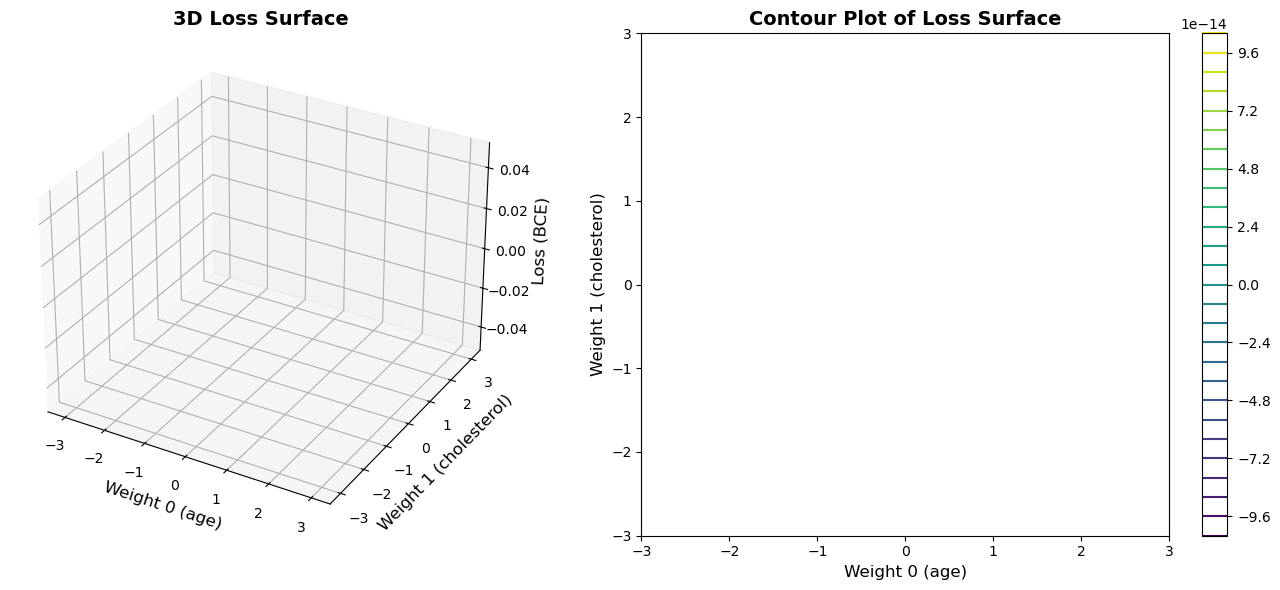

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler


def sigmoid(z):
    return 1/(1+np.exp(-np.clip(z,-500,500)))

def compute_loss(X,y,w0,w1, bias):
    weights = np.array([w0,w1])
    linear_model = np.dot(X[:,:2],weights) + bias
    y_pred = sigmoid(linear_model)
    
    epsilon = 1e-15
    y_pred = np.clip(y_pred,epsilon,epsilon-1)
    loss = -np.mean(y*np.log(y_pred)+(1-y)*np.log(1-y_pred))
    return loss



df = pd.read_csv('datasets\heart_disease_dataset.csv')
X = df[['age','cholesterol']].values
y = df['heart_disease'].values


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


w0_range = np.linspace(-3,3,100)
w1_range = np.linspace(-3,3,100)
W0,W1 = np.meshgrid(w0_range,w1_range)


Z = np.zeros_like(W0)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        Z[i,j] = compute_loss(X_scaled,y,W0[i,j],W1[i,j],bias=0)
        
        
fig = plt.figure(figsize=(14,6))




ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(W0, W1, Z, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Weight 0 (age)', fontsize=12)
ax1.set_ylabel('Weight 1 (cholesterol)', fontsize=12)
ax1.set_zlabel('Loss (BCE)', fontsize=12)
ax1.set_title('3D Loss Surface', fontsize=14, fontweight='bold')






ax2 = fig.add_subplot(122)
contour = ax2.contour(W0, W1, Z, levels=30, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('Weight 0 (age)', fontsize=12)
ax2.set_ylabel('Weight 1 (cholesterol)', fontsize=12)
ax2.set_title('Contour Plot of Loss Surface', fontsize=14, fontweight='bold')
plt.colorbar(contour, ax=ax2)




plt.tight_layout()
plt.savefig('loss_surface.png', dpi=300)
print(" Loss Surface ذخیره شد: loss_surface.png")
plt.show()
           